In [1]:
# ============================================================
# EEP 2024–2050 Analysis
# Data source: DESNZ Energy and Emissions Projections 2024-2050
# ============================================================

In [2]:
# ── Cell 1: 导入库 & 路径设置 ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

GHG_PATH = "C:/Users/888/Desktop/UCL Moduels/AFinal_BENV0096 Dissertation Energy Systems and Data Analytics/Data_raw/A_CB6/final-greenhouse-gas-emissions-tables-2023.xlsx"   
EEP_PATH = "C:/Users/888/Desktop/UCL Moduels/AFinal_BENV0096 Dissertation Energy Systems and Data Analytics/Data_raw/A_CB6/Web_tables_EEP_2024_2050.ods"                      

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

YEARS_HIST = list(range(1990, 2024))
CB_LABELS  = ["CB4\n(2023–27)", "CB5\n(2028–32)", "CB6\n(2033–37)"]
CB_MIDYEARS = [2025, 2030, 2035]   # 各CB期中点年，用于折线拼接

In [3]:
# ── Cell 2: 读取历史排放（Sheet 1.1）────────────────────────
df_11 = pd.read_excel(GHG_PATH, sheet_name="1.1", header=None)
data_rows = list(range(6, 14))
values_11 = df_11.iloc[data_rows, 1:35].astype(float)
values_11.columns = YEARS_HIST
values_11.index = df_11.iloc[data_rows, 0].str.strip().tolist()
total_hist = values_11.loc["Total greenhouse gas emissions"]

print("✅ Historical GHG loaded — 1990:", round(total_hist[1990], 1),
      "| 2023:", round(total_hist[2023], 1), "MtCO₂e")

✅ Historical GHG loaded — 1990: 810.7 | 2023: 385.0 MtCO₂e


In [4]:
# ── Cell 3: 读取 EEP 投影数据（Table 2.1 & 3.1）────────────
df_21 = pd.read_excel(EEP_PATH, sheet_name="Table_2_1", header=None, engine="odf")
df_31 = pd.read_excel(EEP_PATH, sheet_name="Table_3_1", header=None, engine="odf")

# CB 目标与投影（5年合计，MtCO₂e）
cb_targets    = [1950,          1725,          965]
cb_proj_excl  = [float(df_21.iloc[6, 2]),  float(df_21.iloc[6, 3]),  float(df_21.iloc[6, 4])]
cb_proj_incl  = [float(df_21.iloc[7, 2]),  float(df_21.iloc[7, 3]),  float(df_21.iloc[7, 4])]
cb_gap        = [float(df_21.iloc[8, 2]),  float(df_21.iloc[8, 3]),  float(df_21.iloc[8, 4])]

# 政策减排贡献（Table 3.1，5年合计）
policy_savings = [float(df_31.iloc[4, 1]), float(df_31.iloc[4, 2]),
                  float(df_31.iloc[4, 3]), float(df_31.iloc[4, 4])]
policy_labels  = ["CB4\n(2023–27)", "CB5\n(2028–32)", "CB6\n(2033–37)", "CB7\n(2038–42)"]

# 年均排放（用于折线图拼接）
cb_annual_proj = [v / 5 for v in cb_proj_excl]   # exc. IAS 为主基线

print("\n✅ EEP projections loaded:")
for i, lbl in enumerate(CB_LABELS):
    print(f"   {lbl.replace(chr(10),' ')}: Proj={cb_proj_excl[i]:.1f}  "
          f"Target={cb_targets[i]}  Gap={cb_gap[i]:+.1f} MtCO₂e")


✅ EEP projections loaded:
   CB4 (2023–27): Proj=1824.1  Target=1950  Gap=-125.9 MtCO₂e
   CB5 (2028–32): Proj=1638.6  Target=1725  Gap=-86.4 MtCO₂e
   CB6 (2033–37): Proj=1511.6  Target=965  Gap=+737.5 MtCO₂e


In [5]:
display(df_21.iloc[0:12, 0:6])

,0,1,2,3,4
0,Territorial and Net Carbon Account emissions p...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,,units,CB4 (2023-27),CB5 (2028-32),CB6 (2033-37)
4,Carbon budget target,MtCO2e,1950,1725,965
5,Projected territorial and Net Carbon Account (...,NaN,NaN,NaN,NaN
6,Territorial emissions exc. IAS,MtCO2e,1824.055405,1638.641868,1511.590797
7,Territorial emissions inc. IAS,MtCO2e,2032.6562,1841.181047,1702.469409
8,Projected performance vs target (projected NCA...,MtCO2e,-125.944595,-86.358132,737.469409
9,Average annual percentage reduction on base ye...,NaN,NaN,NaN,NaN


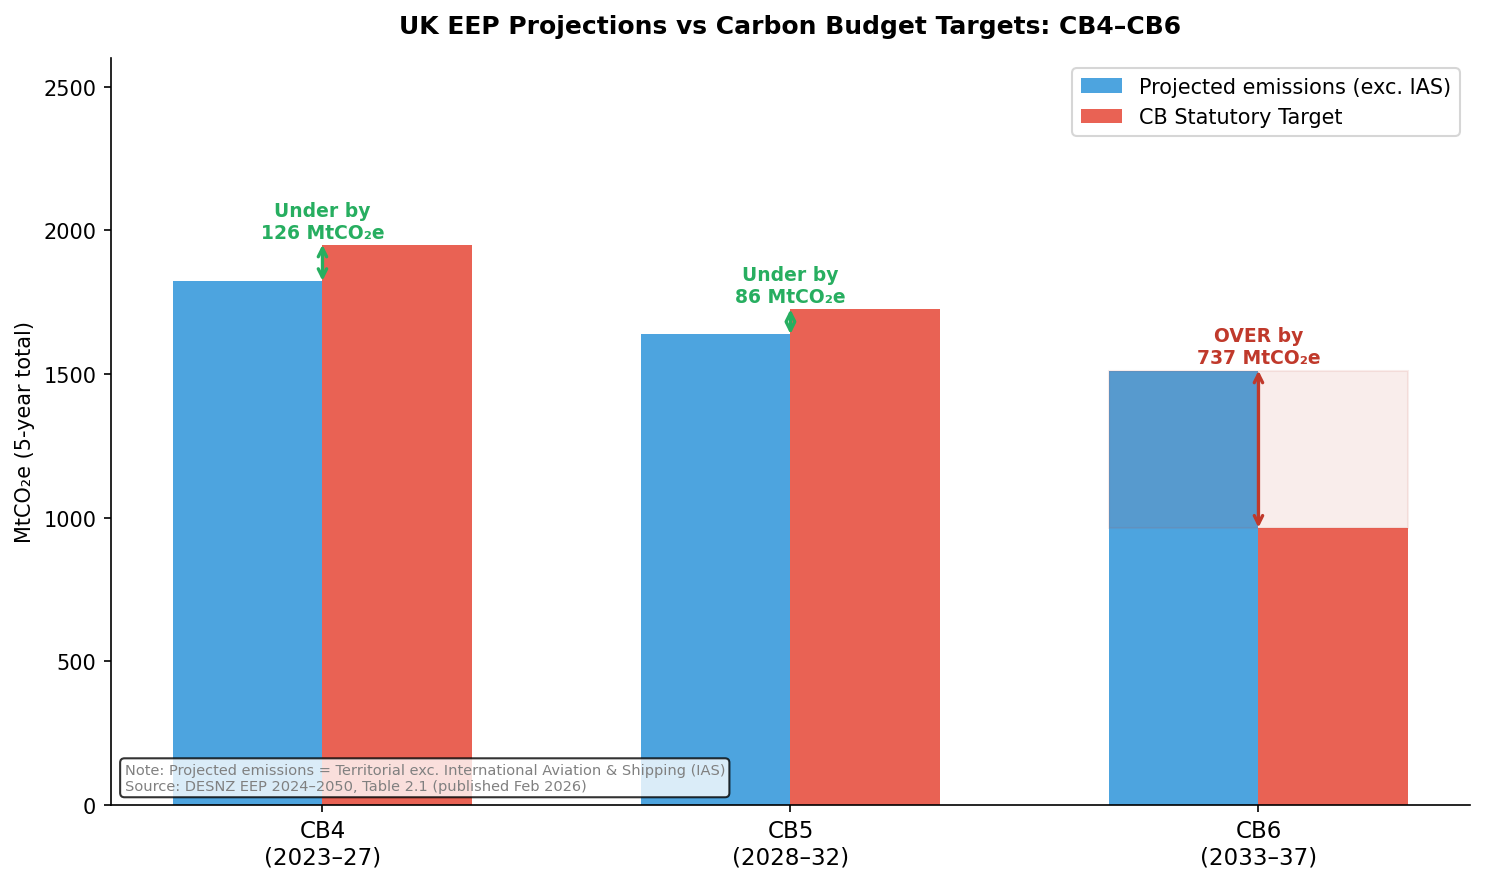

✅ EEP Fig 1 saved: eep_fig1_cb_gap.png


In [9]:
# ── Cell 4 (Fixed): 图1 — CB缺口对比图 ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CB_LABELS))
w = 0.32

bars_proj = ax.bar(x - w/2, cb_proj_excl, w,
                   label="Projected emissions (exc. IAS)",
                   color="#3498db", alpha=0.88)
bars_tgt  = ax.bar(x + w/2, cb_targets, w,
                   label="CB Statutory Target",
                   color="#e74c3c", alpha=0.88)

for i, (proj, tgt, gap) in enumerate(zip(cb_proj_excl, cb_targets, cb_gap)):
    color  = "#27ae60" if gap < 0 else "#c0392b"
    prefix = "Under by" if gap < 0 else "OVER by"
    arrow_x = x[i]
    y_lo = min(proj, tgt)
    y_hi = max(proj, tgt)
    ax.annotate("", xy=(arrow_x, y_hi), xytext=(arrow_x, y_lo),
                arrowprops=dict(arrowstyle="<->", color=color,
                                lw=1.6, shrinkA=0, shrinkB=0))
    ax.text(x[i], y_hi + 25,
            f"{prefix}\n{abs(gap):.0f} MtCO₂e",
            ha="center", fontsize=9, color=color, fontweight="bold")

ax.axvspan(x[2] - w, x[2] + w, ymin=965/2600, ymax=cb_proj_excl[2]/2600,
           alpha=0.09, color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(CB_LABELS, fontsize=11)
ax.set_ylabel("MtCO₂e (5-year total)", fontsize=10)
ax.set_ylim(0, 2600)
ax.set_title("UK EEP Projections vs Carbon Budget Targets: CB4–CB6",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="upper right")

ax.text(0.01, 0.02,
        "Note: Projected emissions = Territorial exc. International Aviation & Shipping (IAS)\n"
        "Source: DESNZ EEP 2024–2050, Table 2.1 (published Feb 2026)",
        transform=ax.transAxes, fontsize=7, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("eep_fig1_cb_gap.png", bbox_inches="tight")
plt.show()
print("✅ EEP Fig 1 saved: eep_fig1_cb_gap.png")


In [11]:
# For the historical + projection trend figure, use a consistent excluding-IAS basis.
# This avoids mixing accounting bases across CB periods.

cb_projection_trend = [
    float(df_21.iloc[6, 2]),  # CB4: territorial emissions exc. IAS
    float(df_21.iloc[6, 3]),  # CB5: territorial emissions exc. IAS
    float(df_21.iloc[6, 4]),  # CB6: territorial emissions exc. IAS
]

cb_targets = [
    float(df_21.iloc[4, 2]),
    float(df_21.iloc[4, 3]),
    float(df_21.iloc[4, 4]),
]

cb_annual_proj = [p / 5 for p in cb_projection_trend]
cb_annual_tgt = [t / 5 for t in cb_targets]

# Official gap row from EEP Table 2.1
# Note: CB6 official gap includes IAS, so do not use it to define the trend line.
cb_gap_official = [
    float(df_21.iloc[8, 2]),
    float(df_21.iloc[8, 3]),
    float(df_21.iloc[8, 4]),
]

# Consistent excluding-IAS gap for the trend figure
cb_gap_trend = [
    cb_projection_trend[i] - cb_targets[i]
    for i in range(3)
]

print("Annual projected emissions, exc. IAS:", cb_annual_proj)
print("Annual targets:", cb_annual_tgt)
print("Gap, exc. IAS:", cb_gap_trend)
print("Official EEP gap row:", cb_gap_official)

Annual projected emissions, exc. IAS: [364.81108104083603, 327.728373581322, 302.318159462986]
Annual targets: [390.0, 345.0, 193.0]
Gap, exc. IAS: [-125.94459479581997, -86.35813209338994, 546.5907973149299]
Official EEP gap row: [-125.944594795819, -86.3581320933886, 737.469408760892]


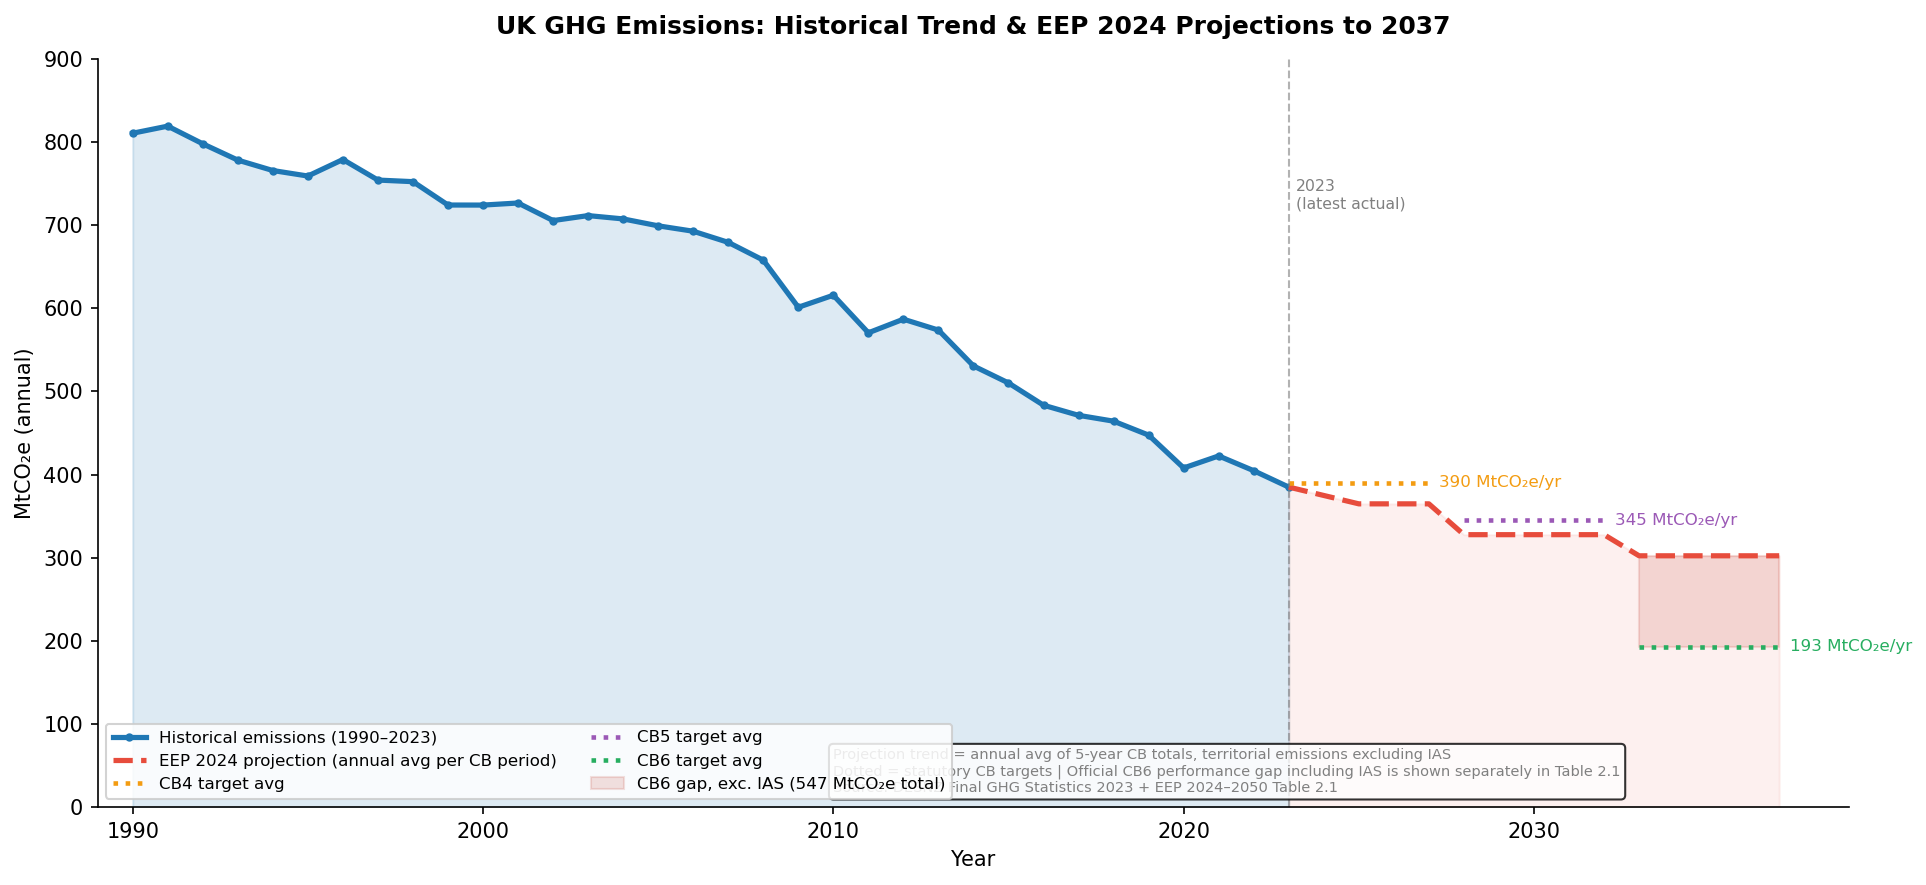

✅ EEP Fig 2 saved: eep_fig2_hist_proj.png


In [12]:
# ── Cell 5 (Fixed): 图2 — 历史 + EEP 投影拼接趋势图 ─────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(YEARS_HIST, total_hist.values, alpha=0.15, color="#1f77b4")
ax.plot(YEARS_HIST, total_hist.values,
        color="#1f77b4", lw=2.5, marker="o", markersize=3,
        label="Historical emissions (1990–2023)")

cb_year_ranges = [(2023, 2027), (2028, 2032), (2033, 2037)]
cb_annual_tgt  = [t / 5 for t in cb_targets]

smooth_years = [2023, 2025, 2027, 2028, 2030, 2032, 2033, 2035, 2037]
smooth_vals  = [
    float(total_hist[2023]),
    cb_annual_proj[0], cb_annual_proj[0],
    cb_annual_proj[1], cb_annual_proj[1], cb_annual_proj[1],
    cb_annual_proj[2], cb_annual_proj[2], cb_annual_proj[2],
]
interp_years = list(range(2023, 2038))
interp_vals  = np.interp(interp_years, smooth_years, smooth_vals)

ax.plot(interp_years, interp_vals,
        color="#e74c3c", lw=2.5, ls="--",
        label="EEP 2024 projection (annual avg per CB period)")
ax.fill_between(interp_years, interp_vals, alpha=0.08, color="#e74c3c")

target_colors = ["#f39c12", "#9b59b6", "#27ae60"]
target_names  = ["CB4 target avg", "CB5 target avg", "CB6 target avg"]
for (y0, y1), tgt_ann, col, name in zip(
        cb_year_ranges, cb_annual_tgt, target_colors, target_names):
    ax.hlines(tgt_ann, y0, y1, colors=col, lw=2.2, ls=":", label=name)
    ax.text(y1 + 0.3, tgt_ann, f"{tgt_ann:.0f} MtCO₂e/yr",
            fontsize=8, color=col, va="center")

ax.fill_between(range(2033, 2038),
                cb_annual_tgt[2], cb_annual_proj[2],
                alpha=0.15, color="#c0392b",
                label=f"CB6 gap, exc. IAS ({cb_gap_trend[2]:.0f} MtCO₂e total)")

ax.axvline(2023, color="grey", lw=1, ls="--", alpha=0.6)
ax.text(2023.2, 720, "2023\n(latest actual)", fontsize=7.5, color="grey")

ax.set_xlim(1989, 2039)
ax.set_ylim(0, 900)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("MtCO₂e (annual)", fontsize=10)
ax.set_title("UK GHG Emissions: Historical Trend & EEP 2024 Projections to 2037",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=8, loc="lower left", framealpha=0.85, ncol=2)

ax.text(0.42, 0.02,
        "Projection trend = annual avg of 5-year CB totals, territorial emissions excluding IAS\n"
        "Dotted = statutory CB targets | Official CB6 performance gap including IAS is shown separately in Table 2.1\n"
        "Source: DESNZ Final GHG Statistics 2023 + EEP 2024–2050 Table 2.1",
        transform=ax.transAxes, fontsize=7, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("eep_fig2_hist_proj.png", bbox_inches="tight")
plt.show()
print("✅ EEP Fig 2 saved: eep_fig2_hist_proj.png")


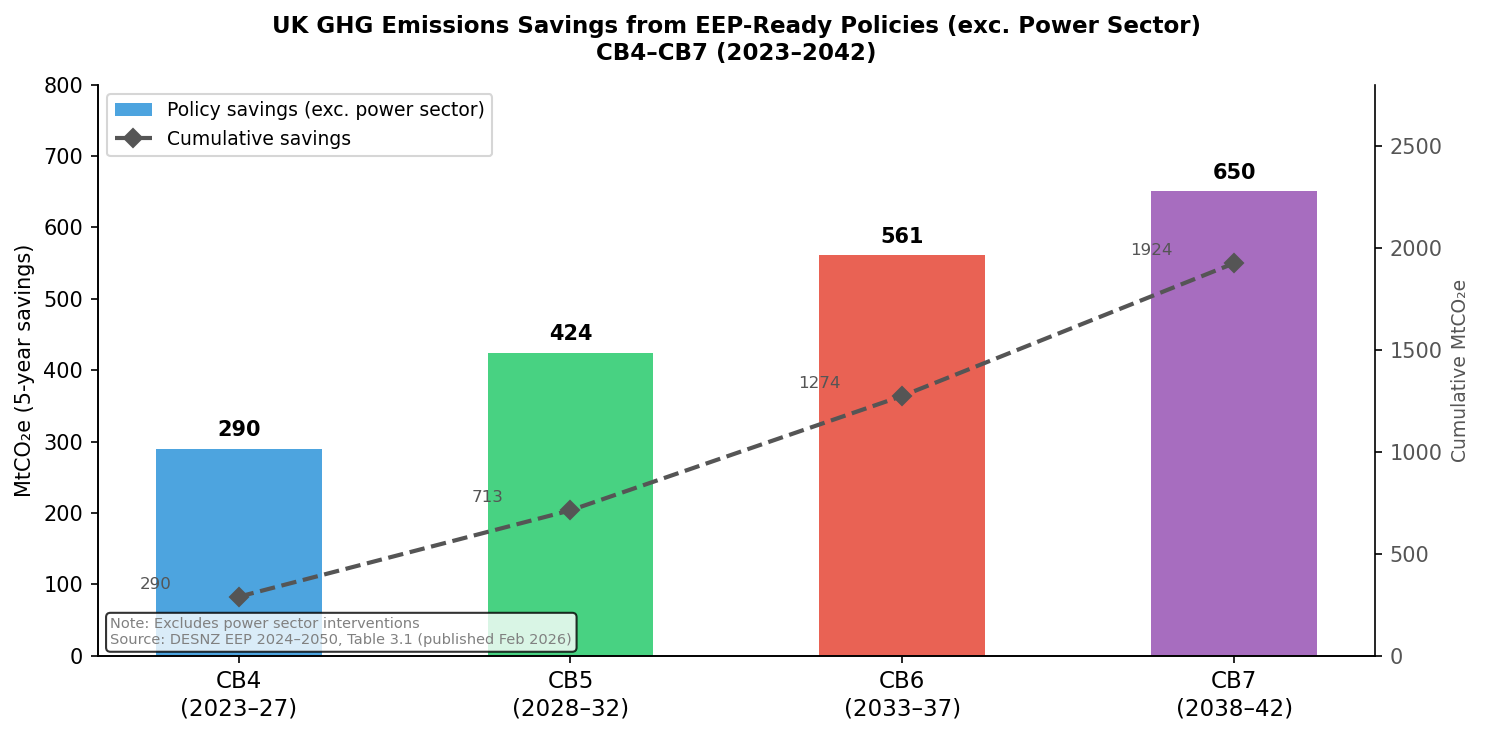

✅ EEP Fig 3 saved: eep_fig3_policy_savings.png


In [11]:
# ── Cell 6 (Fixed): 图3 — 政策贡献减排量 ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(policy_labels))
colors = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"]

bars = ax.bar(x, policy_savings, 0.5,
              color=colors, alpha=0.88,
              label="Policy savings (exc. power sector)")

for bar, val in zip(bars, policy_savings):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 18, f"{val:.0f}",
            ha="center", fontsize=10, fontweight="bold")

cumulative = np.cumsum(policy_savings)
ax2 = ax.twinx()
ax2.plot(x, cumulative, color="#555555", lw=2, ls="--",
         marker="D", markersize=6, label="Cumulative savings")

offsets = [(-0.25, 40), (-0.25, 40), (-0.25, 40), (-0.25, 40)]
for i, val in enumerate(cumulative):
    ax2.text(x[i] + offsets[i][0], val + offsets[i][1],
             f"{val:.0f}", fontsize=8, color="#555555", ha="center")

ax2.set_ylabel("Cumulative MtCO₂e", fontsize=9, color="#555555")
ax2.tick_params(axis="y", labelcolor="#555555")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(True)
ax2.set_ylim(0, 2800)

ax.set_xticks(x)
ax.set_xticklabels(policy_labels, fontsize=11)
ax.set_ylabel("MtCO₂e (5-year savings)", fontsize=10)
ax.set_ylim(0, 800)
ax.set_title("UK GHG Emissions Savings from EEP-Ready Policies (exc. Power Sector)\n"
             "CB4–CB7 (2023–2042)",
             fontsize=11, fontweight="bold", pad=12)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

ax.text(0.01, 0.02,
        "Note: Excludes power sector interventions\n"
        "Source: DESNZ EEP 2024–2050, Table 3.1 (published Feb 2026)",
        transform=ax.transAxes, fontsize=7, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("eep_fig3_policy_savings.png", bbox_inches="tight")
plt.show()
print("✅ EEP Fig 3 saved: eep_fig3_policy_savings.png")


In [8]:
# ── Cell 7: 汇总统计 ─────────────────────────────────────────
print("\n" + "="*65)
print("EEP 2024–2050 Key Findings Summary")
print("="*65)

print("\n📊 CB Period Projections vs Targets (5-year totals, MtCO₂e):")
for i, lbl in enumerate(CB_LABELS):
    status = "ON TRACK" if cb_gap[i] < 0 else "⚠ GAP"
    print(f"   {lbl.replace(chr(10),' '):<14}: "
          f"Proj={cb_proj_excl[i]:.0f}  Target={cb_targets[i]}  "
          f"Gap={cb_gap[i]:+.0f}  [{status}]")

print(f"\n📊 CB6 is the critical gap:")
print(f"   Projected emissions EXCEED target by {cb_gap[2]:.0f} MtCO₂e")
print(f"   Annual average: projected {cb_annual_proj[2]:.0f} vs target {cb_annual_tgt[2]:.0f} MtCO₂e/yr")
print(f"   Annual shortfall: {cb_annual_proj[2] - cb_annual_tgt[2]:.0f} MtCO₂e/yr")

print(f"\n📊 Policy savings (exc. power sector):")
for lbl, sav in zip(policy_labels, policy_savings):
    print(f"   {lbl.replace(chr(10),' '):<14}: {sav:.0f} MtCO₂e saved")
print(f"   Total (2023–42): {sum(policy_savings):.0f} MtCO₂e")

print(f"\n📊 Historical context:")
print(f"   2023 actual: {total_hist[2023]:.1f} MtCO₂e/yr")
print(f"   CB6 target avg: {965/5:.0f} MtCO₂e/yr")
print(f"   Still need to reduce by: {total_hist[2023] - 965/5:.0f} MtCO₂e/yr from 2023 level")


EEP 2024–2050 Key Findings Summary

📊 CB Period Projections vs Targets (5-year totals, MtCO₂e):
   CB4 (2023–27) : Proj=1824  Target=1950  Gap=-126  [ON TRACK]
   CB5 (2028–32) : Proj=1639  Target=1725  Gap=-86  [ON TRACK]
   CB6 (2033–37) : Proj=1512  Target=965  Gap=+737  [⚠ GAP]

📊 CB6 is the critical gap:
   Projected emissions EXCEED target by 737 MtCO₂e
   Annual average: projected 302 vs target 193 MtCO₂e/yr
   Annual shortfall: 109 MtCO₂e/yr

📊 Policy savings (exc. power sector):
   CB4 (2023–27) : 290 MtCO₂e saved
   CB5 (2028–32) : 424 MtCO₂e saved
   CB6 (2033–37) : 561 MtCO₂e saved
   CB7 (2038–42) : 650 MtCO₂e saved
   Total (2023–42): 1924 MtCO₂e

📊 Historical context:
   2023 actual: 385.0 MtCO₂e/yr
   CB6 target avg: 193 MtCO₂e/yr
   Still need to reduce by: 192 MtCO₂e/yr from 2023 level


In [6]:
comparison = pd.DataFrame({
    "Carbon budget": ["CB4 (2023-27)", "CB5 (2028-32)", "CB6 (2033-37)"],
    "Target": df_21.iloc[4, 2:5].astype(float).values,
    "Projected exc. IAS": df_21.iloc[6, 2:5].astype(float).values,
    "Gap exc. IAS": df_21.iloc[6, 2:5].astype(float).values - df_21.iloc[4, 2:5].astype(float).values,
    "Projected inc. IAS": df_21.iloc[7, 2:5].astype(float).values,
    "Gap inc. IAS": df_21.iloc[7, 2:5].astype(float).values - df_21.iloc[4, 2:5].astype(float).values,
    "Official performance row": df_21.iloc[8, 2:5].astype(float).values
})

comparison

,Carbon budget,Target,Projected exc. IAS,Gap exc. IAS,Projected inc. IAS,Gap inc. IAS,Official performance row
0,CB4 (2023-27),1950.0,1824.055405,-125.944595,2032.656200,82.656200,-125.944595
1,CB5 (2028-32),1725.0,1638.641868,-86.358132,1841.181047,116.181047,-86.358132
2,CB6 (2033-37),965.0,1511.590797,546.590797,1702.469409,737.469409,737.469409


In [7]:
official_projection = pd.Series(
    [
        df_21.iloc[6, 2],  # CB4 exc. IAS
        df_21.iloc[6, 3],  # CB5 exc. IAS
        df_21.iloc[7, 4],  # CB6 inc. IAS
    ],
    index=["CB4 (2023-27)", "CB5 (2028-32)", "CB6 (2033-37)"]
).astype(float)

official_target = pd.Series(
    df_21.iloc[4, 2:5].values,
    index=["CB4 (2023-27)", "CB5 (2028-32)", "CB6 (2033-37)"]
).astype(float)

official_gap = pd.Series(
    df_21.iloc[8, 2:5].values,
    index=["CB4 (2023-27)", "CB5 (2028-32)", "CB6 (2033-37)"]
).astype(float)

official_cb_comparison = pd.DataFrame({
    "Projected emissions used for budget comparison": official_projection,
    "Carbon budget target": official_target,
    "Official projected performance vs target": official_gap
})

official_cb_comparison

,Projected emissions used for budget comparison,Carbon budget target,Official projected performance vs target
CB4 (2023-27),1824.055405,1950.0,-125.944595
CB5 (2028-32),1638.641868,1725.0,-86.358132
CB6 (2033-37),1702.469409,965.0,737.469409


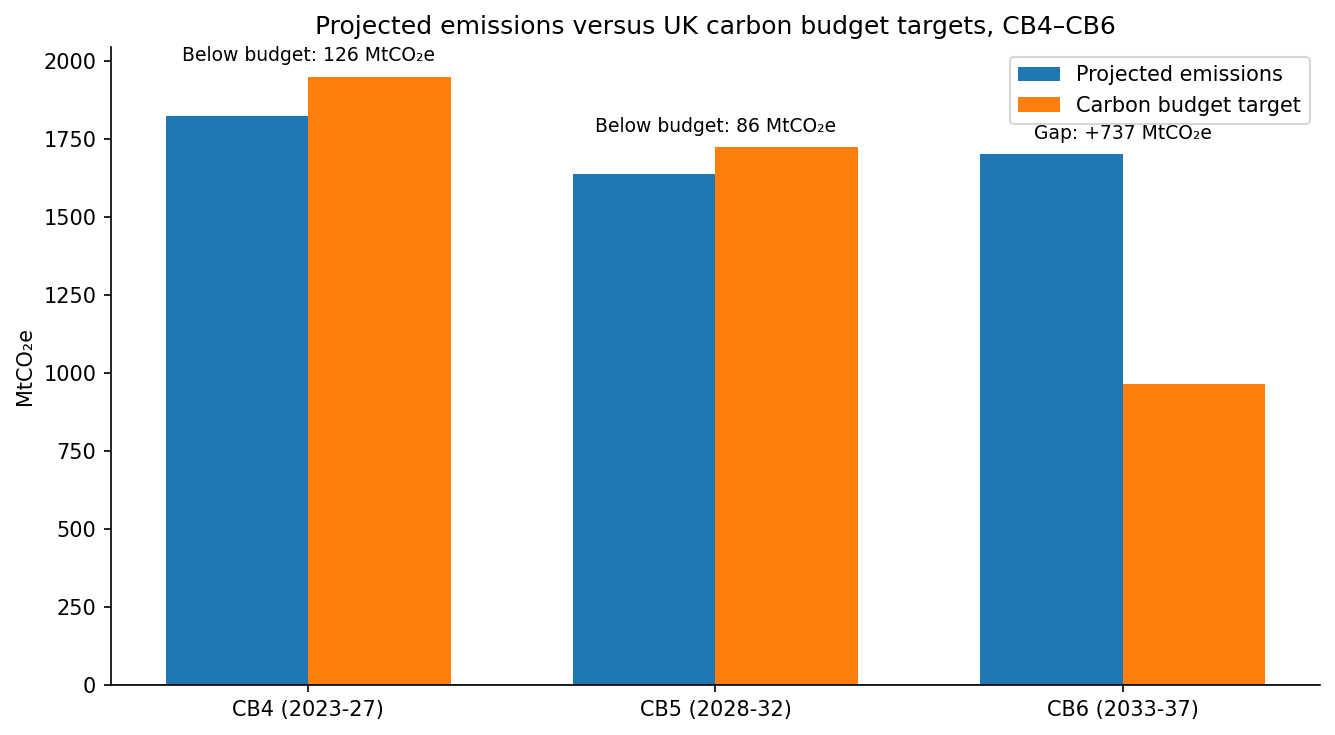

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Use official carbon-budget comparison basis from EEP Table 2.1
plot_df = official_cb_comparison.copy()

labels = plot_df.index.tolist()
projected = plot_df["Projected emissions used for budget comparison"].values
targets = plot_df["Carbon budget target"].values
gaps = plot_df["Official projected performance vs target"].values

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, projected, width, label="Projected emissions")
plt.bar(x + width/2, targets, width, label="Carbon budget target")

plt.axhline(0, linewidth=0.8)

for i, gap in enumerate(gaps):
    if gap > 0:
        text = f"Gap: +{gap:.0f} MtCO₂e"
    else:
        text = f"Below budget: {abs(gap):.0f} MtCO₂e"
    plt.text(
        x[i],
        max(projected[i], targets[i]) + 50,
        text,
        ha="center",
        fontsize=9
    )

plt.xticks(x, labels)
plt.ylabel("MtCO₂e")
plt.title("Projected emissions versus UK carbon budget targets, CB4–CB6")
plt.legend()
plt.tight_layout()
plt.show()